<a href="https://colab.research.google.com/github/Paulo-JPassos/Machine_Learning/blob/main/segmentacao_imagepessoal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [5]:
#bibliotecas auxiliares
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt


In [7]:
!wget -O selfie_multiclass_256x256.tflite \
https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite

--2026-06-27 18:14:31--  https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.181.207, 142.250.152.207, 173.194.193.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.181.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16371837 (16M) [application/octet-stream]
Saving to: ‘selfie_multiclass_256x256.tflite’

selfie_multiclass_2 100%[===================>]  15.61M  --.-KB/s    in 0.07s   

2026-06-27 18:14:31 (219 MB/s) - ‘selfie_multiclass_256x256.tflite’ saved [16371837/16371837]



In [9]:
from google.colab import files

uploaded = files.upload()


Saving FOTO.jpeg to FOTO.jpeg


In [10]:
#configurar segmentador
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(
    model_asset_path='selfie_multiclass_256x256.tflite'
)

options = vision.ImageSegmenterOptions(
    base_options=base_options,
    output_category_mask=True
)

segmenter = vision.ImageSegmenter.create_from_options(
    options
)

In [14]:
#carregar a imagem
image = mp.Image.create_from_file("FOTO.jpeg")


In [15]:
segmentation_result = segmenter.segment(
    image
)

category_mask = segmentation_result.category_mask


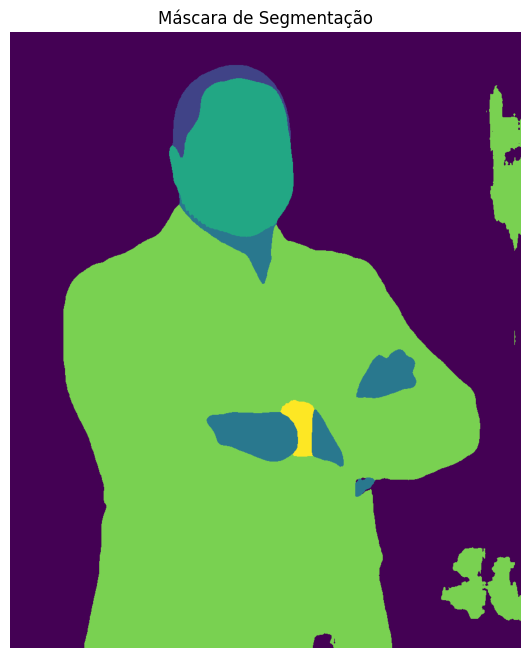

In [16]:
#executar mascara
mask = category_mask.numpy_view()

plt.figure(figsize=(8,8))
plt.imshow(mask)
plt.title("Máscara de Segmentação")
plt.axis("off")
plt.show()

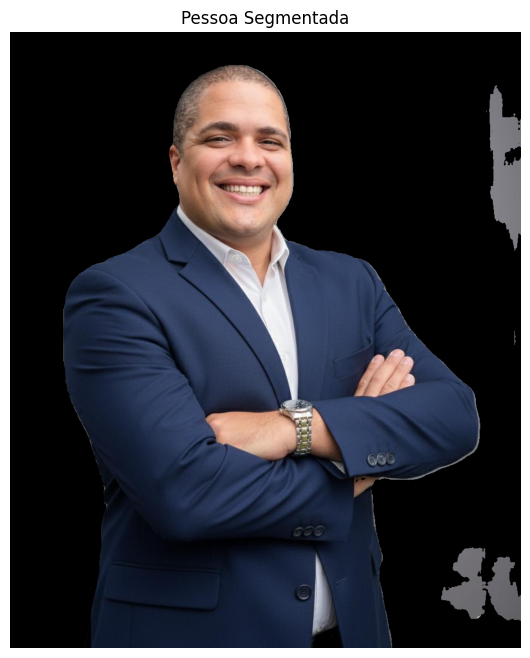

In [18]:
original = cv2.imread("FOTO.jpeg")
original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

mask = np.squeeze(mask)

condition = mask > 0

result = np.zeros_like(original)

result[condition] = original[condition]

plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Pessoa Segmentada")
plt.axis("off")
plt.show()
